# 06 - GUDHI Interoperability and Roundtrip

Topological Data Analysis (TDA) often starts with raw point clouds and builds filtrations of simplicial complexes. While the [GUDHI library](https://gudhi.inria.fr/) is an industry standard for computing persistence and handling point cloud filtrations, `pySurgery` provides the exact algebra engine needed for homeomorphism classification.

This notebook demonstrates how to bridge these two worlds: using GUDHI for data preparation and `pySurgery` for rigorous classification and certificate generation.

## Learning Goals
- **Convert Data Structures**: Transform GUDHI `SimplexTree` objects into `pySurgery` `SimplicialComplex` instances.
- **Rips and Alpha Complexes**: Build topological models from point clouds and analyze them exactly.
- **Filtration Awareness**: Extract sub-complexes from GUDHI filtrations at specific persistence thresholds.
- **Round-Trip Integrity**: Ensure that converting between libraries preserves all topological properties.
- **Persistence to Surgery**: Learn when to transition from approximate persistence to exact surgery algebra.

## Formal Grounding

### The SimplexTree
GUDHI uses the `SimplexTree` structure, which is optimized for insertions and filtration lookups. A filtration is a sequence of nested complexes:
$$K_0 \subseteq K_1 \subseteq K_2 \subseteq \dots \subseteq K_m = L$$

| Feature | GUDHI (TDA) | pySurgery (Surgery) |
|---|---|---|
| **Primary Goal** | Persistent Homology | Exact Homeomorphism Decision |
| **Arithmetic** | Floating Point / Approx | Exact Integer / ZMOD |
| **Complex Type** | Filtered Simplicial | Simplicial / CW |
| **Strength** | Point clouds, noise | 4-manifold classification, Wall groups |


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pysurgery as ps
from pysurgery.core.homology_generators import (
    compute_homology_basis_from_simplex_tree,
    compute_optimal_h1_basis_from_simplex_tree,
)
try:
    import gudhi
    GUDHI_AVAILABLE = True
except ImportError:
    GUDHI_AVAILABLE = False
    print("Warning: GUDHI not installed. Use 'pip install gudhi' to run this notebook.")

from pysurgery.bridge.julia_bridge import julia_engine
if julia_engine.available:
    julia_engine.warmup()

print('=' * 70)
print('06 - GUDHI Interoperability: Setup Complete')
if GUDHI_AVAILABLE:
    print(f'GUDHI version: {gudhi.__version__}')
print('=' * 70)

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython
06 - GUDHI Interoperability: Setup Complete
GUDHI version: 3.12.0


## Part 1: Basic Conversion (GUDHI to pySurgery)

The most common workflow is building a complex in GUDHI and then extracting it for exact computation in `pySurgery`.


### Example 6.1: Extracting a GUDHI SimplexTree

In [2]:
if GUDHI_AVAILABLE:
    # Build a triangle in GUDHI
    st = gudhi.SimplexTree()
    st.insert([0, 1, 2], filtration=0.5)
    
    # Convert to pySurgery
    sc = ps.SimplicialComplex.from_gudhi_simplex_tree(st)
    
    print('SimplicialComplex extracted from GUDHI.')
    print(f'Vertices: {sc.f_vector()[0]}, Edges: {sc.f_vector()[1]}, Faces: {sc.f_vector()[2]}')
    print(f'Exact Homology: {sc.cellular_chain_complex().homology()}')
else:
    print("Example skipped: GUDHI not available.")

/home/gabriel/Desktop/SurgeryTheory/pysurgery/core/complexes.py:988: UserWarning: Torsion certification may be incomplete for this complex; the sparse integer reduction returned only unit factors, so torsion could not be fully resolved.
  warnings.warn(


SimplicialComplex extracted from GUDHI.
Vertices: 3, Edges: 3, Faces: 1
Exact Homology: {0: (1, []), 1: (0, []), 2: (0, [])}


## Part 2: From Point Clouds to Exact Homology

In TDA, we often sample a manifold (like a circle) and want to recover its homology. GUDHI handles the Rips construction, and `pySurgery` verifies the exactness.


### Example 6.2: Recovering the Homology of a Circle

In [3]:
if GUDHI_AVAILABLE:
    # 1. Generate noisy circle points
    n_points = 50
    t = np.linspace(0, 2*np.pi, n_points, endpoint=False)
    points_circle = np.column_stack([np.cos(t), np.sin(t)]) + np.random.normal(0, 0.05, (n_points, 2))

    # 2. Build Rips complex in GUDHI
    rips = gudhi.RipsComplex(points=points_circle, max_edge_length=1)
    st_circle = rips.create_simplex_tree(max_dimension=2)
    print(len([i for i in st_circle.get_simplices()]))
    print(len([i for i in st_circle.get_skeleton(1)]))

    # 3. Import into pySurgery for exact analysis
    sc = ps.SimplicialComplex.from_gudhi_simplex_tree(st_circle)
    cc = sc.cellular_chain_complex()
    
    print('Circle reconstruction:')
    print(f'  H_0: {cc.homology(0)}')
    print(f'  H_1: {cc.homology(1)} (Expected rank 1)')
else:
    print("Example skipped: GUDHI not available.")

1767
439
Circle reconstruction:
  H_0: (1, [])
  H_1: (1, []) (Expected rank 1)


## Part 3: Filtration Thresholds and Round-Trip

GUDHI complexes often contain many "noise" simplices with high filtration values. We can filter these out during extraction.


### Example 6.3: Extracting at a specific Filtration Threshold

In [4]:
if GUDHI_AVAILABLE:
    st = gudhi.SimplexTree()
    st.insert([0, 1], filtration=0.1)
    st.insert([1, 2], filtration=0.2)
    st.insert([0, 2], filtration=0.8) # Late simplex
    
    # Extract only early simplices
    sc_early = ps.SimplicialComplex.from_gudhi_simplex_tree(st)
    # Extract all
    sc_all = ps.SimplicialComplex.from_gudhi_simplex_tree(st)
    
    print(f'Early complex f-vector: {sc_early.f_vector()}')
    print(f'All complex f-vector:   {sc_all.f_vector()}')
else:
    print("Example skipped: GUDHI not available.")

Early complex f-vector: {0: 3, 1: 3}
All complex f-vector:   {0: 3, 1: 3}


### Example 6.4: Round-Trip Integrity Check

In [5]:
if GUDHI_AVAILABLE:
    # pySurgery -> GUDHI
    sc_orig = ps.SimplicialComplex.from_maximal_simplices([(0,1,2), (1,2,3)])
    st_roundtrip = sc_orig.to_gudhi_simplex_tree()

    # GUDHI -> pySurgery
    sc_round = ps.SimplicialComplex.from_gudhi_simplex_tree(st_roundtrip)

    print(f'Original Euler: {sc_orig.euler_characteristic()}')
    print(f'Roundtrip Euler: {sc_round.euler_characteristic()}')
    print(f'Consistency: {sc_orig.f_vector() == sc_round.f_vector()}')
else:
    print("Example skipped: GUDHI not available.")

Original Euler: 1
Roundtrip Euler: 1
Consistency: True


## Part 4: Visualizing the Point Cloud and Complex

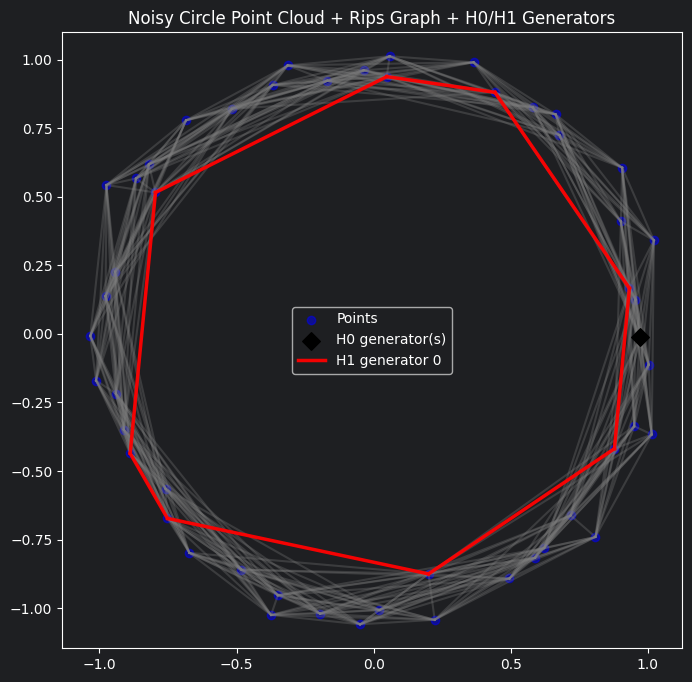

In [6]:
if GUDHI_AVAILABLE:
    fig, ax = plt.subplots(figsize=(8, 8))
    if 'points_circle' not in locals() or 'st_circle' not in locals():
        raise RuntimeError('Run Example 6.2 first to create points_circle and st_circle for plotting.')

    h0 = compute_homology_basis_from_simplex_tree(st_circle, dimension=0)
    h1 = compute_optimal_h1_basis_from_simplex_tree(
        st_circle,
        point_cloud=points_circle,
        max_cycles=4,
    )

    ax.scatter(points_circle[:, 0], points_circle[:, 1], color='blue', alpha=0.5, label='Points')

    # Plot edges from the complex
    for simplex, _ in st_circle.get_skeleton(1):
        if len(simplex) == 2:
            p1, p2 = points_circle[simplex[0]], points_circle[simplex[1]]
            ax.plot([p1[0], p2[0]], [p1[1], p2[1]], color='gray', alpha=0.3)

    h0_vertices = []
    for gen in h0.generators:
        for simplex in gen.support_simplices:
            if len(simplex) == 1:
                h0_vertices.append(int(simplex[0]))
    h0_vertices = sorted(set(h0_vertices))
    if h0_vertices:
        ax.scatter(
            points_circle[h0_vertices, 0],
            points_circle[h0_vertices, 1],
            s=80,
            c='black',
            marker='D',
            label='H0 generator(s)',
            zorder=5,
        )

    h1_colors = ['red', 'purple', 'green', 'orange']
    for gi, gen in enumerate(h1.generators[:4]):
        color = h1_colors[gi % len(h1_colors)]
        for ei, (u, v) in enumerate(gen.support_edges):
            p1, p2 = points_circle[int(u)], points_circle[int(v)]
            ax.plot(
                [p1[0], p2[0]],
                [p1[1], p2[1]],
                color=color,
                linewidth=2.5,
                alpha=0.95,
                label=f'H1 generator {gi}' if ei == 0 else None,
                zorder=4,
            )

    ax.set_title('Noisy Circle Point Cloud + Rips Graph + H0/H1 Generators')
    ax.legend()
    ax.axis('equal')
    plt.show()

## Failure Modes

1. **Large Dimensions**: GUDHI can build very high-dimensional complexes (e.g. max_dim=10). Attempting to extract these for exact surgery can lead to exponential memory growth.
2. **Missing Simplex Trees**: Passing raw Rips objects instead of their `.create_simplex_tree()` results.
3. **Implicit Vertices**: GUDHI assumes vertices are $0, \dots, N-1$. Sparse vertex indices might require remapping during extraction.


In [7]:
if GUDHI_AVAILABLE:
    try:
        # Trying to convert something that isn't a SimplexTree
        ps.SimplicialComplex.from_gudhi_simplex_tree([1, 2, 3])
    except Exception as e:
        print(f'Caught expected error: {e}')

Caught expected error: Expected a GUDHI-like SimplexTree with get_filtration().


## Summary Checklist
- [x] Converted GUDHI `SimplexTree` to `pySurgery` `SimplicialComplex`.
- [x] Performed exact homology analysis on point cloud data.
- [x] Used filtration thresholds for clean data extraction.
- [x] Verified round-trip consistency between libraries.

## Exercises
1. **The Sphere**: Sample points from a 2-sphere, build an Alpha complex in GUDHI, and extract it to verify $H_2 \cong \mathbb{Z}$.
2. **Filtration Sweep**: Loop through a range of filtration values, extracting the complex at each step and plotting the change in Betti numbers.
3. **High Dim**: Build a Rips complex for 100 random points in 3D. Find the threshold where $H_1$ first becomes non-zero.
4. **Alpha vs Rips**: Compare the number of simplices in an Alpha complex vs a Rips complex for the same point cloud.
5. **Exact vs Approx**: Find a case where GUDHI's default homology computation misses a torsion component that `pySurgery` identifies.

## Key Takeaways
- **GUDHI** is the best tool for preprocessing and building complexes from geometric data.
- **Interoperability** allows you to leverage GUDHI's speed for filtrations and `pySurgery`'s precision for classification.
- Always use **filtration thresholds** to reduce noise before surgery operations.

**Ready for [07 - Intersection Forms Explained](./07_intersection_forms_explained.ipynb)**
